In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random


Creating our dataset for the project

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

np.random.seed(42)

# -----------------------------
# CONFIG (you can tweak size)
# -----------------------------
NUM_USERS = 5000
MAX_SESSIONS_PER_USER = 20

START_DATE = datetime(2025, 1, 1)
END_DATE = datetime(2025, 3, 31)

cities = ["Delhi", "Mumbai", "Bangalore", "Hyderabad", "Pune"]
devices = ["Android", "iOS"]
plans = ["monthly", "yearly"]

# -----------------------------
# 1. USERS TABLE
# -----------------------------
users = []

for user_id in range(1, NUM_USERS + 1):
    signup_date = START_DATE + timedelta(days=np.random.randint(0, 30))
    city = random.choice(cities)
    device = random.choice(devices)

    users.append([user_id, signup_date, city, device])

users_df = pd.DataFrame(users, columns=["user_id", "signup_date", "city", "device"])

# -----------------------------
# 2. EVENTS TABLE
# -----------------------------
events = []
event_id = 1
session_id = 1

for _, row in users_df.iterrows():
    user_id = row["user_id"]
    signup_date = row["signup_date"]

    num_sessions = np.random.randint(1, MAX_SESSIONS_PER_USER)

    for _ in range(num_sessions):
        session_time = signup_date + timedelta(days=np.random.randint(0, 60))

        # app_open (always happens)
        events.append([event_id, user_id, session_id, "app_open", session_time])
        event_id += 1

        # search
        if np.random.rand() < 0.75:
            events.append([event_id, user_id, session_id, "search_song", session_time + timedelta(minutes=1)])
            event_id += 1

            # play
            if np.random.rand() < 0.75:
                events.append([event_id, user_id, session_id, "play_song", session_time + timedelta(minutes=2)])
                event_id += 1

                # like
                if np.random.rand() < 0.6:
                    events.append([event_id, user_id, session_id, "like_song", session_time + timedelta(minutes=3)])
                    event_id += 1

                    # playlist
                    if np.random.rand() < 0.5:
                        events.append([event_id, user_id, session_id, "add_to_playlist", session_time + timedelta(minutes=4)])
                        event_id += 1

                        # premium conversion
                        if np.random.rand() < 0.6:
                            events.append([event_id, user_id, session_id, "subscribe_premium", session_time + timedelta(minutes=5)])
                            event_id += 1

        session_id += 1

events_df = pd.DataFrame(events, columns=[
    "event_id", "user_id", "session_id", "event_type", "event_time"
])

# -----------------------------
# 3. SUBSCRIPTIONS TABLE
# -----------------------------
subscriptions = []
sub_id = 1

premium_users = events_df[events_df["event_type"] == "subscribe_premium"]["user_id"].unique()

for user_id in premium_users:
    sub_date = START_DATE + timedelta(days=np.random.randint(10, 70))
    plan = random.choice(plans)

    amount = 99 if plan == "monthly" else 999

    subscriptions.append([sub_id, user_id, sub_date, plan, amount])
    sub_id += 1

subscriptions_df = pd.DataFrame(subscriptions, columns=[
    "subscription_id", "user_id", "subscription_date", "plan_type", "amount"
])

# -----------------------------
# SAVE FILES
# -----------------------------
users_df.to_csv("users.csv", index=False)
events_df.to_csv("events.csv", index=False)
subscriptions_df.to_csv("subscriptions.csv", index=False)

print("✅ Dataset generated successfully!")
print(f"Users: {len(users_df)}")
print(f"Events: {len(events_df)}")
print(f"Subscriptions: {len(subscriptions_df)}")

✅ Dataset generated successfully!
Users: 5000
Events: 145107
Subscriptions: 2938


In [ ]:
from google.colab import files

files.download("users.csv")
files.download("events.csv")
files.download("subscriptions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
users=pd.read_csv('users (1).csv')
event=pd.read_csv('events.csv')
subscrip=pd.read_csv('subscriptions.csv')

In [ ]:
users

,user_id,signup_date,city,device
0,1,2025-01-07,Mumbai,Android
1,2,2025-01-20,Hyderabad,iOS
2,3,2025-01-29,Pune,Android
3,4,2025-01-15,Bangalore,iOS
4,5,2025-01-11,Bangalore,Android
...,...,...,...,...
4995,4996,2025-01-13,Delhi,Android
4996,4997,2025-01-04,Bangalore,Android
4997,4998,2025-01-02,Mumbai,Android
4998,4999,2025-01-16,Bangalore,iOS


In [ ]:
event['event_type'].value_counts()

,count
event_type,
app_open,49713
search_song,37235
play_song,27988
like_song,16746
add_to_playlist,8392
subscribe_premium,5033


Setup for using sql in google colab



In [ ]:
import sqlite3

conn = sqlite3.connect(":memory:")

In [ ]:
users.to_sql("users", conn, index=False, if_exists="replace")
event.to_sql("events", conn, index=False, if_exists="replace")
subscrip.to_sql("subscriptions", conn, index=False, if_exists="replace")

2938

Defining our funnel

In [ ]:
# now i am defining my funnel as app_open->search_song->play_song->like_song->add_to_playlist->subscribe_premium

Funnel Analysis

In [ ]:
# I am first finding that how many unique users are there at each stage of our experiment

In [ ]:
# next i will find out the percentage of users that are converting or moving from one stage to another.
# for ex i have 100 users who opened app and 96 users who are searching song then we can say that (96/100)*100 percent of
# users are moving from opening app to searching song.

In [ ]:
query="""
with cte as
(select *,
round(((1.0*cou/(lag(cou) over(order by
case
  when event_type='app_open' then 1
  when event_type='search_song' then 2
  when event_type='play_song' then 3
  when event_type='like_song' then 4
  when event_type='add_to_playlist' then 5
  when event_type='subscribe_premium' then 6
end)))*100.0),2) as percen_conv
from
(select event_type,count(distinct(user_id)) as cou from events
group by event_type))

select *,100.0-percen_conv as dropped_user_percen from cte

"""

pd.read_sql(query,conn)

,event_type,cou,percen_conv,dropped_user_percen
0,app_open,5000,NaN,NaN
1,search_song,4926,98.52,1.48
2,play_song,4808,97.60,2.40
3,like_song,4483,93.24,6.76
4,add_to_playlist,3712,82.80,17.20
5,subscribe_premium,2938,79.15,20.85


In [ ]:
# hence we can see here that we loose 20.85 percent of users from add_to_playlist to subscribe_premium stage

In [ ]:
query="""
with cte as
(select *,round(((1.0*cou/lag(cou) over(partition by device
order by
case
  when event_type='app_open' then 1
  when event_type='search_song' then 2
  when event_type='play_song' then 3
  when event_type='like_song' then 4
  when event_type='add_to_playlist' then 5
  when event_type='subscribe_premium' then 6
end))*100.0),2) as percen_conv from
(select event_type,device,count(distinct(t1.user_id)) as cou from events t1
join users t2
on t1.user_id=t2.user_id
group by event_type,device))

select *,100.0-percen_conv as drop_percen_of_users from cte
order by
case
  when event_type='app_open' then 1
  when event_type='search_song' then 2
  when event_type='play_song' then 3
  when event_type='like_song' then 4
  when event_type='add_to_playlist' then 5
  when event_type='subscribe_premium' then 6
end,device


"""

pd.read_sql(query,conn)

,event_type,device,cou,percen_conv,drop_percen_of_users
0,app_open,Android,2507,NaN,NaN
1,app_open,iOS,2493,NaN,NaN
2,search_song,Android,2471,98.56,1.44
3,search_song,iOS,2455,98.48,1.52
4,play_song,Android,2408,97.45,2.55
5,play_song,iOS,2400,97.76,2.24
6,like_song,Android,2253,93.56,6.44
7,like_song,iOS,2230,92.92,7.08
8,add_to_playlist,Android,1864,82.73,17.27
9,add_to_playlist,iOS,1848,82.87,17.13


In [ ]:
# “The highest drop-off (~21%) occurs at the transition from playlist creation to premium subscription across
# both Android and iOS users, indicating that the
# issue is not device-specific but likely related to pricing, value perception, or subscription friction.

In [ ]:
# A significant drop (~17%) is observed between liking a song and adding it to a playlist,
# suggesting users are not engaging deeply with content.

In [ ]:
# Conversion and drop-off patterns are very similar across Android and iOS, indicating that user behavior is consistent
# and the issue is
# product-driven rather than platform-specific.

In [ ]:
# Early stages (app_open → play_song) show very high conversion (>95%), indicating strong initial engagement.

Retention Analysis

In [ ]:
# calculating first_engagment date for each user

query="""
select user_id,min(event_time) as first_engag from events
group by user_id
"""

pd.read_sql(query,conn)


,user_id,first_engag
0,1,2025-01-08 00:00:00
1,2,2025-01-27 00:00:00
2,3,2025-01-29 00:00:00
3,4,2025-01-18 00:00:00
4,5,2025-01-18 00:00:00
...,...,...
4995,4996,2025-01-14 00:00:00
4996,4997,2025-01-04 00:00:00
4997,4998,2025-01-02 00:00:00
4998,4999,2025-03-03 00:00:00


In [ ]:
# difference between current_date and first_usage date for each user

query = """
SELECT
    user_id,
    DATE(event_time) AS activity_date,
    MIN(DATE(event_time)) OVER (PARTITION BY user_id) AS first_date,

    julianday(DATE(event_time)) -
    julianday(MIN(DATE(event_time)) OVER (PARTITION BY user_id))
    AS difference

FROM events
"""

pd.read_sql(query,conn)

,user_id,activity_date,first_date,difference
0,1,2025-02-13,2025-01-08,36.0
1,1,2025-02-13,2025-01-08,36.0
2,1,2025-02-08,2025-01-08,31.0
3,1,2025-01-29,2025-01-08,21.0
4,1,2025-01-29,2025-01-08,21.0
...,...,...,...,...
145102,5000,2025-03-06,2025-01-18,47.0
145103,5000,2025-03-06,2025-01-18,47.0
145104,5000,2025-03-06,2025-01-18,47.0
145105,5000,2025-02-17,2025-01-18,30.0


In [ ]:
# here i am calculating how many percent of users who registered on day 0 are actually again visiting our app on day 1
# after registering,day 2 after registering and so on.

query = """
with cte as
(select difference,
count(distinct(user_id)) as cou
from
(SELECT
    user_id,
    DATE(event_time) AS activity_date,
    MIN(DATE(event_time)) OVER (PARTITION BY user_id) AS first_date,

    julianday(DATE(event_time)) -
    julianday(MIN(DATE(event_time)) OVER (PARTITION BY user_id))
    AS difference

FROM events) t
group by difference)

select *,
round(((cou*100.0/max(case when difference=0.0 then cou end) over())),2) as ret_percen

 from cte
"""

df=pd.read_sql(query,conn)


In [ ]:
df

,difference,cou,ret_percen
0,0.0,5000,100.00
1,1.0,727,14.54
2,2.0,731,14.62
3,3.0,732,14.64
4,4.0,785,15.70
5,5.0,758,15.16
6,6.0,686,13.72
7,7.0,730,14.60
8,8.0,772,15.44
9,9.0,735,14.70


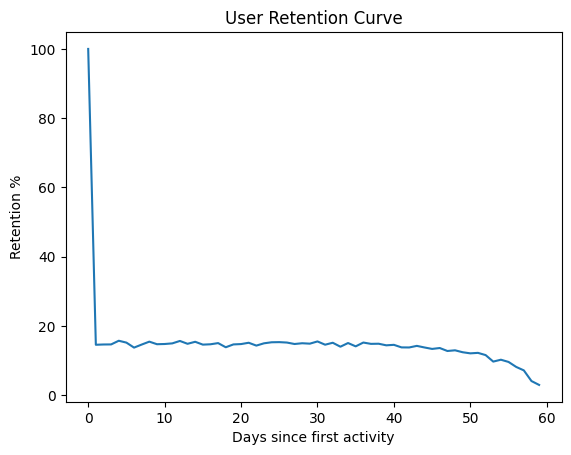

In [ ]:
import matplotlib.pyplot as plt
plt.plot(df['difference'],df['ret_percen'])
plt.xlabel('Days since first activity')
plt.ylabel('Retention %')
plt.title('User Retention Curve')
plt.show()

In [ ]:
# Sharp drop in retention after Day 0 (~85% drop)
# → Indicates poor early user engagement or onboarding issues

# Stable retention (~14–16%) from Day 1 to Day 40
# → Suggests a core group of users consistently engage with the product
# Gradual decline after Day 45
# → Indicates long-term churn among retained users

Cohort Analysis Starts

In [ ]:
query="""
with cte as
(select first_date,days_since,count(distinct(user_id)) as cou from
(select user_id,date(event_time) as inter_date,min(date(event_time)) over(partition by user_id
) as first_date,julianday(DATE(event_time)) -
    julianday(MIN(DATE(event_time)) OVER (PARTITION BY user_id))
    AS days_since from events) t
    group by first_date,days_since)

select *,round(((cou*1.0/max(case when days_since=0.0 then cou end) over(partition by first_date))*100.0),2) as percen from cte
"""

df=pd.read_sql(query,conn)

In [ ]:
df['days_since'] = df['days_since'].astype(int)

In [ ]:
df

,first_date,days_since,cou,percen
0,2025-01-01,0,24,100.00
1,2025-01-01,1,1,4.17
2,2025-01-01,2,3,12.50
3,2025-01-01,3,6,25.00
4,2025-01-01,4,6,25.00
...,...,...,...,...
2891,2025-03-21,0,3,100.00
2892,2025-03-22,0,2,100.00
2893,2025-03-26,0,1,100.00
2894,2025-03-27,0,1,100.00


In [ ]:
cohort_table = df.pivot(
    index='first_date',
    columns='days_since',
    values='percen'
)

cohort_table = cohort_table.sort_index()
cohort_table = cohort_table.fillna(0)

In [ ]:
cohort_table

days_since,0,1,2,3,4,5,6,7,8,9,...,50,51,52,53,54,55,56,57,58,59
first_date,,,,,,,,,,,,,,,,,,,,,
2025-01-01,100.0,4.17,12.50,25.00,25.00,12.50,25.00,4.17,20.83,16.67,...,20.83,16.67,25.00,12.50,25.00,16.67,16.67,25.00,4.17,4.17
2025-01-02,100.0,12.50,27.08,8.33,25.00,22.92,14.58,22.92,25.00,27.08,...,25.00,10.42,18.75,27.08,20.83,16.67,18.75,14.58,8.33,8.33
2025-01-03,100.0,13.70,8.22,15.07,13.70,13.70,20.55,17.81,19.18,10.96,...,5.48,16.44,16.44,16.44,10.96,16.44,20.55,13.70,6.85,10.96
2025-01-04,100.0,15.48,13.10,10.71,19.05,20.24,10.71,19.05,19.05,19.05,...,13.10,10.71,25.00,21.43,21.43,20.24,19.05,16.67,7.14,5.95
2025-01-05,100.0,23.47,15.31,26.53,15.31,12.24,16.33,14.29,14.29,15.31,...,18.37,17.35,22.45,14.29,14.29,21.43,16.33,16.33,7.14,8.16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-21,100.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2025-03-22,100.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2025-03-26,100.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


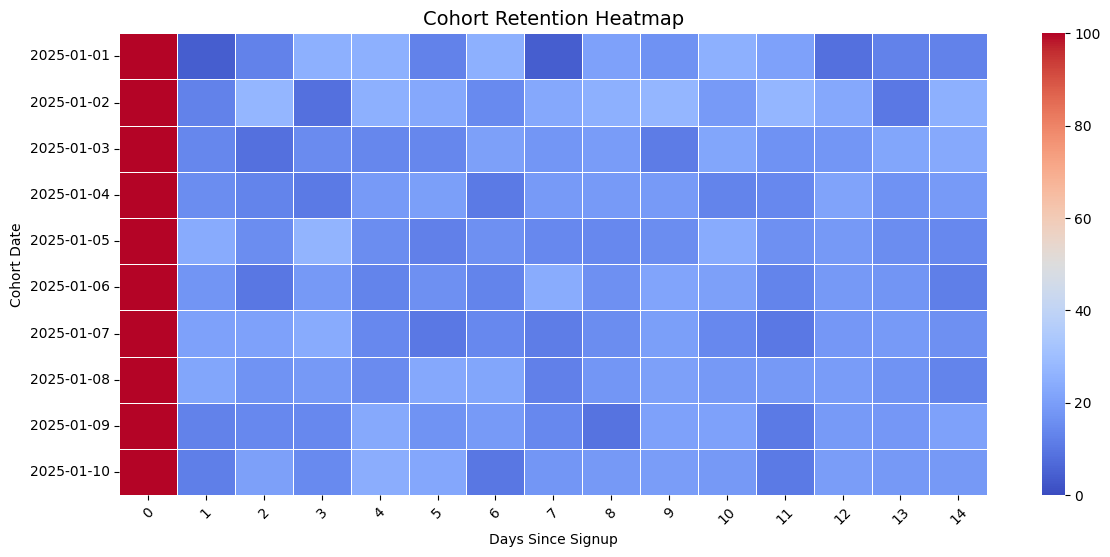

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cohort_small = cohort_table.iloc[:10, :15]

plt.figure(figsize=(14, 6))

sns.heatmap(
    cohort_small,
    annot=False,        # remove numbers
    cmap="coolwarm",
    vmin=0,
    vmax=100,
    linewidths=0.5
)

plt.title("Cohort Retention Heatmap", fontsize=14)
plt.xlabel("Days Since Signup")
plt.ylabel("Cohort Date")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

In [ ]:
cohort_small

days_since,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
first_date,,,,,,,,,,,,,,,
2025-01-01,100.0,4.17,12.50,25.00,25.00,12.50,25.00,4.17,20.83,16.67,25.00,20.83,8.33,12.50,12.50
2025-01-02,100.0,12.50,27.08,8.33,25.00,22.92,14.58,22.92,25.00,27.08,18.75,27.08,22.92,10.42,25.00
2025-01-03,100.0,13.70,8.22,15.07,13.70,13.70,20.55,17.81,19.18,10.96,21.92,16.44,17.81,21.92,23.29
2025-01-04,100.0,15.48,13.10,10.71,19.05,20.24,10.71,19.05,19.05,19.05,13.10,14.29,21.43,16.67,19.05
2025-01-05,100.0,23.47,15.31,26.53,15.31,12.24,16.33,14.29,14.29,15.31,23.47,16.33,18.37,15.31,14.29
2025-01-06,100.0,17.39,9.78,18.48,13.04,16.30,13.04,23.91,16.30,21.74,20.65,13.04,18.48,17.39,11.96
2025-01-07,100.0,20.95,20.95,23.81,14.29,10.48,14.29,11.43,15.24,20.00,14.29,10.48,18.10,19.05,16.19
2025-01-08,100.0,22.12,16.81,18.58,15.04,23.01,22.12,12.39,17.70,20.35,18.58,18.58,19.47,16.81,13.27
2025-01-09,100.0,12.61,14.41,14.41,23.42,17.12,18.92,14.41,9.01,20.72,20.72,10.81,18.92,18.02,20.72


In [ ]:
# Day-1 retention is low (~10–20%), indicating weak onboarding or initial user experience.

In [ ]:
# Retention fluctuates significantly across days, suggesting users are not forming consistent usage habits.

In [ ]:
# Retention trends remain similar across cohorts, indicating no measurable improvement in user engagement over time.

In [ ]:
# Occasional spikes in retention suggest that external triggers such as notifications or new content
# may temporarily drive user activity.

In [ ]:
# Retention stabilizes at a low level (~10–20%), indicating a small but consistent user base with limited long-term growth.